1. Setup


In [2]:
import sys
import os
import pandas as pd

# Add src to path
sys.path.append(os.path.abspath(os.path.join('..', 'src')))

from utils import load_data
from features import compute_features

2. Load Data

In [3]:
X_train, y_train, X_test = load_data()

Loading data from c:\Users\ANKRI\Desktop\Q1\ELEN0062-1\Project3\Football-pass-prediction\data\raw...


3. Process a small chunk first to test!

In [4]:
# (Processing all 8000+ samples creates 8000 * 22 = ~176,000 rows)
print("Processing training set...")
train_features = compute_features(X_train.head(100), y_train.head(100))

print("\nShape:", train_features.shape)
print(train_features.head())

Processing training set...
Generating PRO features (Blockage, Congestion) for 100 passes...

Shape: (2200, 16)
   pass_id  candidate_id  sender_id    feat_dist  feat_angle  feat_team  \
0        0             1         14  2188.743932    0.301522          0   
1        0             2         14  2280.109646   -0.312042          0   
2        0             3         14  3244.842061   -0.547819          0   
3        0             4         14  3538.997033    0.590354          0   
4        0             5         14  1254.950198    0.712083          0   

   feat_fwd  feat_pressure  feat_congestion  feat_blockage  feat_packing  \
0   -2090.0            0.0                1            0.0             4   
1   -2170.0            0.0                1            0.0             5   
2   -2770.0            0.0                1            0.0             6   
3   -2940.0            0.0                1            0.0             7   
4    -950.0            0.0                1            0.0

4. Simple correlation check

In [5]:
# Does 'dist_to_sender' correlate with receiving the ball?
print("\nCorrelations with Target:")
print(train_features.corr()['target'].sort_values(ascending=False))


Correlations with Target:
target             1.000000e+00
feat_team          1.571169e-01
feat_blockage      1.559996e-01
feat_pressure      1.088642e-01
candidate_id       2.614093e-02
feat_angle         1.404158e-02
rank_fwd           1.163384e-02
sender_id         -1.728648e-17
pass_id           -2.097893e-16
feat_fwd          -1.377285e-02
feat_packing      -1.162372e-01
feat_congestion   -1.338433e-01
feat_dist         -1.353682e-01
rank_blockage     -1.426487e-01
rank_dist         -1.595972e-01
rank_pressure     -1.726126e-01
Name: target, dtype: float64


Correlation Heatmap

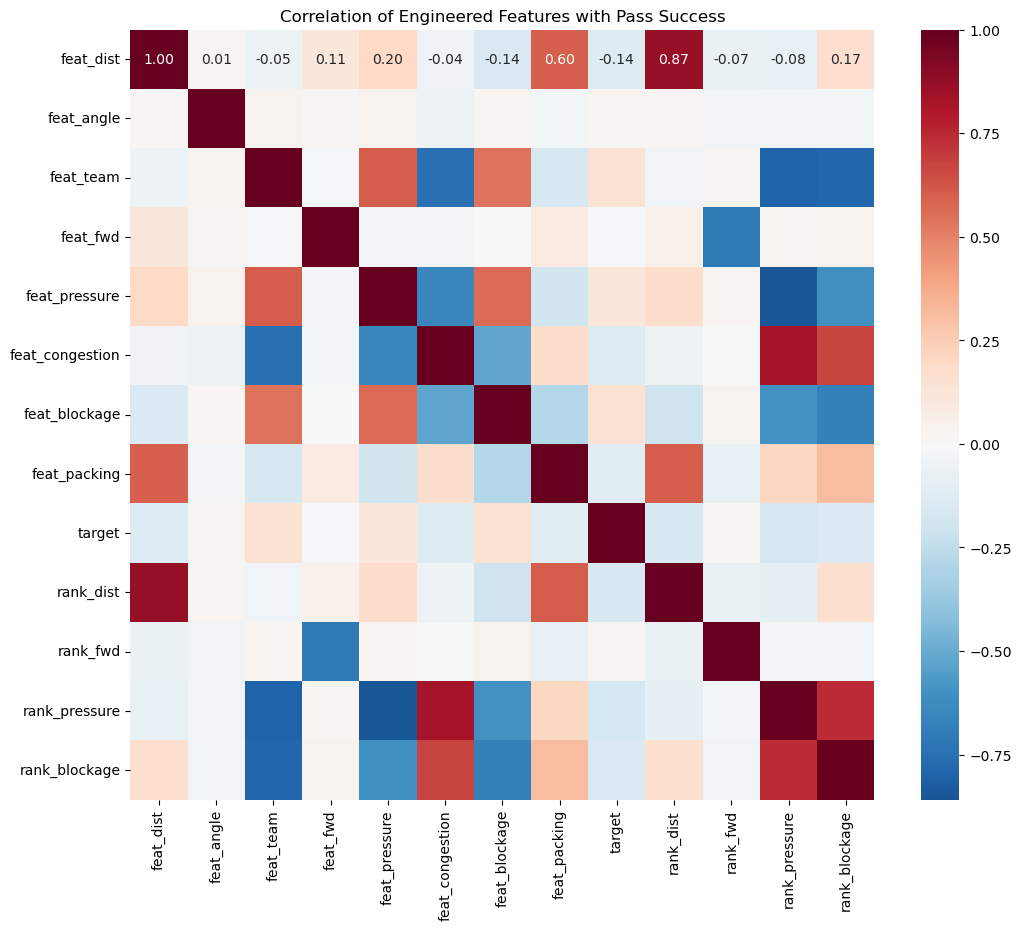

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
# Filter only engineered features and target
eda_cols = [c for c in train_features.columns if 'feat' in c or 'rank' in c or c == 'target']
sns.heatmap(train_features[eda_cols].corr(), annot=True, cmap='RdBu_r', center=0, fmt=".2f")
plt.title("Correlation of Engineered Features with Pass Success")
plt.savefig('correlation_heatmap.png')
plt.show()

Feature Separation Boxplots

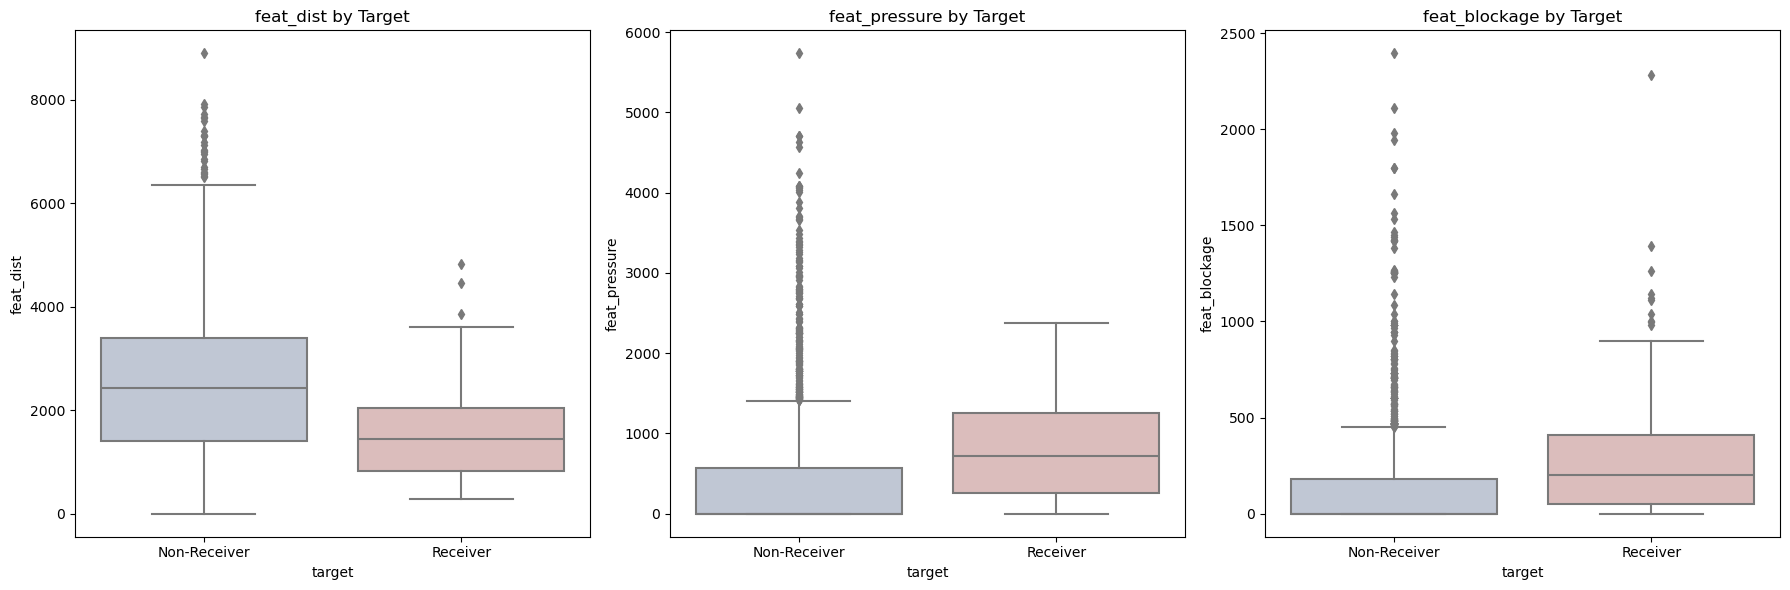

In [8]:
# We pick the 3 most promising features based on your correlation list
top_features = ['feat_dist', 'feat_pressure', 'feat_blockage']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, feat in enumerate(top_features):
    sns.boxplot(ax=axes[i], x='target', y=feat, data=train_features, palette='vlag')
    axes[i].set_title(f'{feat} by Target')
    axes[i].set_xticklabels(['Non-Receiver', 'Receiver'])

plt.tight_layout()
plt.savefig('feature_separation.png')
plt.show()

Conceptual Pitch Visualization

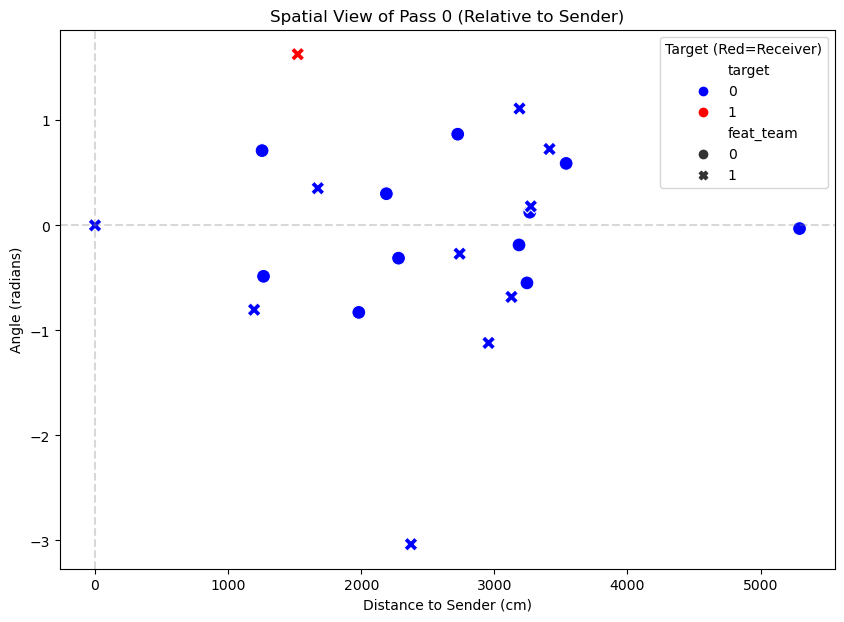

In [9]:
# Visualize the first pass in your chunk
sample_pass_id = train_features['pass_id'].iloc[0]
pass_data = train_features[train_features['pass_id'] == sample_pass_id]

plt.figure(figsize=(10, 7))
# Plot the pitch (conceptual bounds)
plt.axhline(0, color='gray', linestyle='--', alpha=0.3)
plt.axvline(0, color='gray', linestyle='--', alpha=0.3)

# Plot sender and candidates
sns.scatterplot(data=pass_data, x='feat_dist', y='feat_angle', hue='target', 
                style='feat_team', s=100, palette={0: 'blue', 1: 'red'})

plt.title(f"Spatial View of Pass {sample_pass_id} (Relative to Sender)")
plt.xlabel("Distance to Sender (cm)")
plt.ylabel("Angle (radians)")
plt.legend(title="Target (Red=Receiver)")
plt.savefig('pass_spatial_logic.png')
plt.show()

5. Generate Features for the Whole Dataset

In [7]:

print("Processing FULL training set ")
df_train_features = compute_features(X_train, y_train) 

# Save it so you don't have to re-compute it every time!
df_train_features.to_csv('../data/processed/train_features.csv', index=False)
print("Saved processed features to data/processed/train_features.csv")

Processing FULL training set 
Generating PRO features (Blockage, Congestion) for 8686 passes...
Saved processed features to data/processed/train_features.csv
